# Credit Card Fraud Detection
   
   My first data science project! The goal is to build a model that predicts whether a credit card transaction is fraudulent.
   
   **Dataset:** Credit Card Fraud from Kaggle (`mlg-ulb/creditcardfraud`)

## Step 1: Import Libraries
   
   Loading the tools we need:
   - `kagglehub` to download the dataset
   - `pandas` (aliased as `pd`) to handle data tables

In [ ]:
import kagglehub
import pandas as pd

print("Imports worked!")

Imports worked!


## Step 2: Download the Dataset
   
   Downloading the credit card fraud dataset from Kaggle. It saves to a cache folder on my computer (not the project folder, to keep things clean).

In [ ]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dataset downloaded to: /kaggle/input/creditcardfraud


## Step 3: Load Data into a DataFrame

Reading the CSV file into a pandas DataFrame called `df`. This loads all 284,807 transactions into memory so I can work with them instantly.

In [ ]:
df = pd.read_csv(f"{path}/creditcard.csv")
print("Data loaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Data loaded
Rows: 284807
Columns: 31


## Step 4: First Look at the Data

Using `.head()` to see the first 5 rows and `.tail()` for the last 5.
The columns V1–V28 are anonymized (PCA-transformed) for privacy.
`Class` is our target: 0 = legitimate, 1 = fraud.

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## Step 5: Inspect the Data

Checking data types, missing values, and basic statistics before doing any analysis. Always look before leaping

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#### At the amount section, we can see that
- smallest transaction min=0 , smallest transaction is $0
- mean (average) is 88.35 , which is $88.35 per average transaction
- 50% of transactions are at $22

#### IMPORTANT at Class:
- min=0 , max =1 , this means that its (legit or fraud)
- the mean = 0.001727 means that there are 0.17% fraudulent transactions


In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Step 6: Check the Class Imbalance

Counting how many legitimate vs fraudulent transactions we have.

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
fraud_count = (df['Class'] == 1).sum()
legit_count = (df['Class'] == 0).sum()
total = len(df)

print(f"Legitimate transactions: {legit_count:,} ({legit_count/total*100:.2f}%)")
print(f"Fraudulent transactions: {fraud_count:,} ({fraud_count/total*100:.4f}%)")
print(f"Ratio: 1 fraud for every {legit_count // fraud_count:,} legitimate transactions")

Legitimate transactions: 284,315 (99.83%)
Fraudulent transactions: 492 (0.1727%)
Ratio: 1 fraud for every 577 legitimate transactions


## Step 7: Visualize the Class Imbalance

A chart makes the imbalance impossible to ignore. Using `matplotlib` and `seaborn` to make it look nice.    

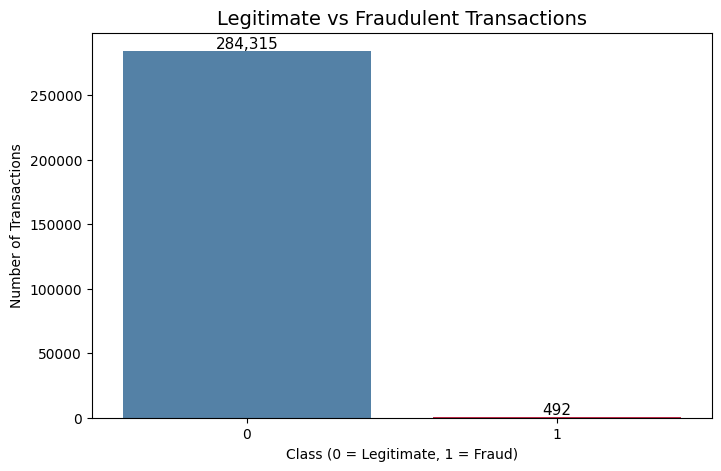

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, hue='Class', palette=['steelblue', 'crimson'], legend= False)

# Add labels and title
plt.title('Legitimate vs Fraudulent Transactions', fontsize=14)
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions')

# Add exact numbers on top of each bar
for i, count in enumerate(df['Class'].value_counts().sort_index()):
    plt.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=11)

plt.show()

## Machine Learning time, i am going to separate features (X) from target (y)

Splitting the dataset:
- `X` = all the information about a transaction (inputs)
- `y` = whether it was fraud or not (the answer we want to predict)

In [ ]:
X = df.drop('Class', axis=1)   # all columns EXCEPT Class
y = df['Class']                # ONLY the Class column

print("Shape of X (features):", X.shape)
print("Shape of y (target):  ", y.shape)
print("\nFirst 3 rows of X:")
print(X.head(3))
print("\nFirst 3 values of y:")
print(y.head(3))

Shape of X (features): (284807, 30)
Shape of y (target):   (284807,)

First 3 rows of X:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   

         V8        V9  ...       V20       V21       V22       V23       V24  \
0  0.098698  0.363787  ...  0.251412 -0.018307  0.277838 -0.110474  0.066928   
1  0.085102 -0.255425  ... -0.069083 -0.225775 -0.638672  0.101288 -0.339846   
2  0.247676 -1.514654  ...  0.524980  0.247998  0.771679  0.909412 -0.689281   

        V25       V26       V27       V28  Amount  
0  0.128539 -0.189115  0.133558 -0.021053  149.62  
1  0.167170  0.125895 -0.008983  0.014724    2.69  
2 -0.327642 -0.139097 -0.055353 -0.059752  378.66  

[3 rows x 30 columns]

First 3 values of y:
0    0
1    

## Splitting data into training and testing set
- now that 'x' and 'y' has been split, i am going to split 80% training and 20% to test if results are learned correctly


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% goes to test, 80% to train
    random_state=42,     # so the split is the same every time we run
    stratify=y           # keeps the same fraud ratio in both sets
)

print("Training set shape:", X_train.shape)
print("Training answers shape:", y_train.shape)
print("Testing set shape:", X_test.shape)
print("Testing answers shape:", y_test.shape)

Training set shape: (227845, 30)
Training answers shape: (227845,)
Testing set shape: (56962, 30)
Testing answers shape: (56962,)


## Scaling the Amount Column

The V columns are already small numbers, but Amount goes up to 25,000.
Big numbers can confuse the model, so I'm rescaling Amount to match.
Also dropping Time since it's not useful here.

Important: only `fit_transform` on training data, then `transform` test data —
never let the model peek at test data during scaling!

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler tool
scaler = StandardScaler()

# Rescale the Amount column in the TRAINING set (fit + transform)
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])

# Rescale the Amount column in the TESTING set (transform only!)
X_test['Amount'] = scaler.transform(X_test[['Amount']])

# Drop the Time column from both sets
X_train = X_train.drop('Time', axis=1)
X_test = X_test.drop('Time', axis=1)

print("Scaling complete!")
print("\nAmount stats after scaling (training set):")
print(X_train['Amount'].describe())
print("\nNew shape of X_train:", X_train.shape)
print("New shape of X_test: ", X_test.shape)

Scaling complete!

Amount stats after scaling (training set):
count    2.278450e+05
mean    -2.020811e-17
std      1.000002e+00
min     -3.516894e-01
25%     -3.291944e-01
50%     -2.639429e-01
75%     -4.262209e-02
max      1.021170e+02
Name: Amount, dtype: float64

New shape of X_train: (227845, 29)
New shape of X_test:  (56962, 29)


## Training My First Model: Logistic Regression

I'm using Logistic Regression
, a classic starting model that's simple, fast, and great for beginners like me

Steps:
1. Create the model
2. Train (fit) it on the training data
3. Use it to predict fraud on the test data

In [ ]:
from sklearn.linear_model import LogisticRegression

# Step 1: Create the model
model = LogisticRegression(max_iter=1000, random_state=42)

# Step 2: Train it on the training data (this is where it learns!)
model.fit(X_train, y_train)

# Step 3: Use the trained model to predict on the test data
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("Number of predictions made:", len(y_pred))
print("Predicted frauds:", (y_pred == 1).sum())
print("Predicted legit:", (y_pred == 0).sum())

Model trained successfully!
Number of predictions made: 56962
Predicted frauds: 76
Predicted legit: 56886


## Evaluating the Model

Time to see how well the model did. Because fraud is so rare, I can't just
look at accuracy, it must be checked:
- **Precision:** how many of my fraud predictions were correct?
- **Recall:** how many of the real frauds did I catch?
- **Confusion matrix:** the full picture of correct vs wrong predictions.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Overall accuracy (not the most important, but let's see it)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.4f}%")

# The confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Full report with precision, recall, and more
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Legit (0)', 'Fraud (1)']))

Accuracy: 99.9157%

Confusion Matrix:
[[56851    13]
 [   35    63]]

Classification Report:
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



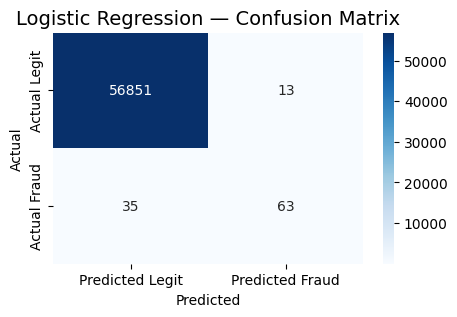

In [ ]:
# Confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred)

# Draw heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Legit', 'Predicted Fraud'],
    yticklabels=['Actual Legit', 'Actual Fraud']
)
plt.title('Logistic Regression — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Confusion Matrix Results

| Outcome | Count | What it means |
|---|---|---|
| True Negatives | 56,851 | Correctly said "not fraud" for 56,851 legit transactions |
| False Positives | 13 | Wrongly flagged 13 legit transactions as fraud (false alarms, customers get "was this you?" texts) |
| False Negatives | 35 | Missed 35 real frauds (fraudster got away, bank loses money) |
| True Positives | 63 | Caught 63 real frauds |

## Trying a Better Model: Random Forest

My first model caught only 64% of frauds. Let me try a stronger model —
Random Forest — which builds many "decision trees" and averages them for a
smarter prediction.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,     # build 100 decision trees
    random_state=42,      # freeze randomness
    n_jobs=-1             # use all CPU cores (faster)
)

# Train it (this will take longer — 30 sec to 2 min)
print("Training Random Forest... ")
rf_model.fit(X_train, y_train)
print("Training done! ")

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Legit (0)', 'Fraud (1)']))

Training Random Forest... 
Training done! 

Confusion Matrix:
[[56859     5]
 [   17    81]]

Classification Report:
              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00     56864
   Fraud (1)       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



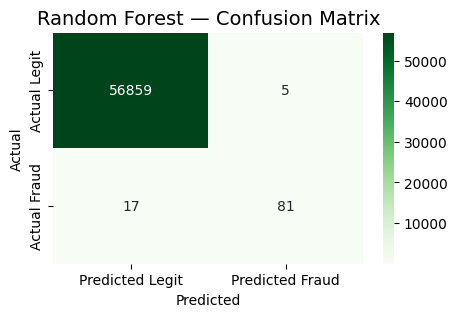

In [ ]:
# Confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Draw heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',      # different color to distinguish from LR heatmap
    xticklabels=['Predicted Legit', 'Predicted Fraud'],
    yticklabels=['Actual Legit', 'Actual Fraud']
)
plt.title('Random Forest — Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Conclusion

### What I built
A machine learning pipeline to detect fraudulent credit card transactions using
284,807 anonymized transactions from Kaggle.

### The challenge
The dataset is extremely imbalanced (only 0.17% fraud). This means accuracy
alone is misleading, so I focused on precision and recall for the fraud class.

### Models compared

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Frauds caught (out of 98) | 63 | 81 |
| Frauds missed | 35 | 17 |
| False alarms | 13 | 5 |
| Precision (fraud) | 83% | 94% |
| Recall (fraud) | 64% | 83% |

### Winner
Random Forest clearly outperformed Logistic Regression, catching more frauds
with fewer false alarms.